# Energy Futures Forward Inflation OLS Model

This notebook will examine energy futures using 5y5y forward inflation with in-sample OLS and signal optimization. 

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
energy_tickers = ["CL", "CO", "HO", "NG", "QS", "XB"]
inf_tickers    = ["FWISBP55", "FWISUS55"]

In [3]:
data_path = r"A:\BBGData\data"
inf_paths = [os.path.join(data_path, ticker + ".parquet") for ticker in inf_tickers]
df_inf    = (pd.read_parquet(
    path = inf_paths, engine = "pyarrow").
    assign(country = lambda x: np.where(x.security.str.split(" ").str[0] == "FWISBP55", "UK", "US")))

In [4]:
fut_path   = r"A:\BBGFuturesManager_backup_backup\data\PXFront"
fut_paths  = [os.path.join(fut_path, ticker + ".parquet") for ticker in energy_tickers]
df_fut_rtn = (pd.read_parquet(
    path = fut_paths, engine = "pyarrow").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

df_perf = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(rtn_type = "perfect"))

df_lagged = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna().
    assign(rtn_type = "lagged"))

df_rtn = pd.concat([df_perf, df_lagged])

# Section 1: Trading Based on $\beta$ of full sample OLS

This model is done by fitting the log changes in 5y5y forward inflation then getting the $\beta$ and using that as the trading singal. 

In [5]:
df_combined = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x)).
    diff().
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "inf_diff").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date"]))

In [6]:
def _ols_rtn(df: pd.DataFrame) -> pd.DataFrame:
    
    model = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit())
    
    beta        = model.params.to_list()[-1]
    beta_tvalue = model.tvalues.to_list()[-1] 
    
    df_out = (df.assign(
        beta       = beta,
        t_value    = beta_tvalue,
        signal_rtn = lambda x: np.sign(x.beta * x.inf_diff) * x.fut_rtn))
    
    return df_out

df_model = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_ols_rtn, include_groups = False).
    reset_index())

In [7]:
df_wider = (df_model.pivot(
    index = "date", columns = "group_var", values = "signal_rtn"))

df_lagged = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rsk_rtn").
    assign(group = "lagged"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rsk_rtn").
    assign(group = "perfect"))

df_rsk_rtn = (pd.concat([
    df_lagged, df_perf]).
    merge(right = df_model, how = "inner", on = ["date", "group_var"]))

In [8]:
def _get_rtn_ols_params(df: pd.DataFrame) -> pd.DataFrame: 
    
    model = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit())
    
    df_param   = model.params.to_frame(name = "param_val").reset_index()
    df_pvalues = model.pvalues.to_frame(name = "pvalues").reset_index()
    df_tstats  = model.tvalues.to_frame(name = "tstat").reset_index()
    
    df_out = (df_param.merge(
        right = df_pvalues, how = "inner", on = ["index"]).
        merge(right = df_tstats, how = "inner", on = ["index"]))
    
    return df_out

df_ols_params = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_rtn_ols_params).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        country  = lambda x: x.group_var.str.split(" ").str[0],
        security = lambda x: x.group_var.str.split(" ").str[1]))

In [9]:
(df_ols_params.drop(
    columns = ["group_var"]).
    melt(id_vars = ["index", "country", "security"]).
    replace({
        "param_val": "Param. Val",
        "pvalues"  : r"$p$-value",
        "tstat"    : r"$t$-stat",
        "const"    : r"$\alpha$",
        "inf_diff" : r"$\beta$"}).
    rename(columns = {
        "index"   : "Param.",
        "variable": "",
        "country" : "Country"}).
    pivot(index = ["Country", "security"], columns = ["", "Param."], values = "value").
    apply(lambda x: np.round(x,3)))

Param. Val         $p$-value         $t$-stat        
Param.             $\alpha$ $\beta$  $\alpha$ $\beta$ $\alpha$ $\beta$
Country security                                                      
UK      CL1           0.000   0.040     0.419   0.178    0.809   1.347
        CO1           0.000   0.033     0.379   0.195    0.880   1.297
        HO1           0.001   0.042     0.098   0.104    1.655   1.628
        NG1           0.000  -0.022     0.656   0.783    0.445  -0.275
        QS1           0.000   0.056     0.287   0.022    1.065   2.286
        XB1           0.001   0.022     0.048   0.453    1.979   0.751
US      CL1           0.000   0.008     0.535   0.640    0.620   0.468
        CO1           0.000   0.016     0.507   0.260    0.663   1.127
        HO1           0.000   0.010     0.203   0.467    1.273   0.728
        NG1           0.000   0.011     0.671   0.808    0.424   0.243
        QS1           0.000   0.011     0.484   0.406    0.699   0.831
        XB1           0.001   0.021     0.055   0.194    1.921   1.299

Above is a table of the regression results. Depending on pvalue level of acceptance the results at statistically significant. Two securities XB and NG don't fit well with the model. 

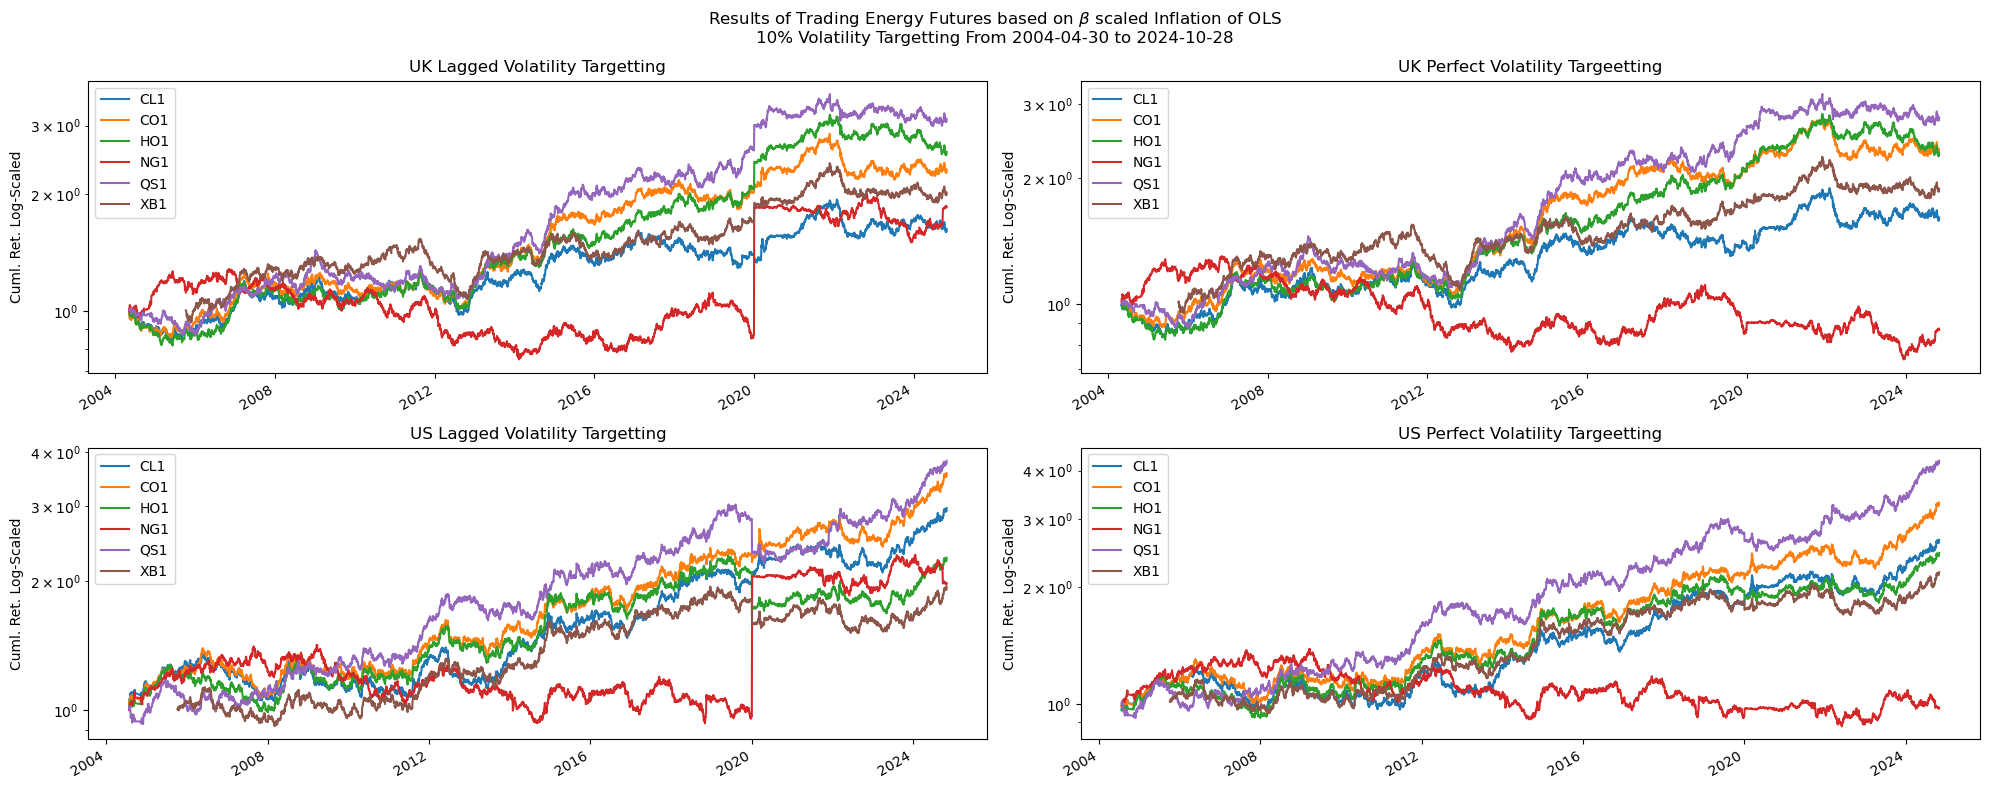

In [10]:
df_plot = (df_rsk_rtn[
    ["date", "country", "group", "security", "rsk_rtn"]].
    assign(group_var = lambda x: x.country + " " + x.group))

group_vars = df_plot.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (20,8))

vrenamer = {
    "lagged" : "Lagged Volatility Targetting",
    "perfect": "Perfect Volatility Targeetting"}

for group_var, ax in zip(group_vars, axes.flatten()): 
    
    (df_plot.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "rsk_rtn").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            xlabel = "",
            title  = "{} {}".format(group_var.split(" ")[0], vrenamer[group_var.split(" ")[1]])))

fig.suptitle(
    r"Results of Trading Energy Futures based on $\beta$ scaled Inflation of OLS"
    + "\n"
    + "10% Volatility Targetting From {} to {}".format(df_plot.date.min().date(), df_plot.date.max().date())
)

plt.tight_layout()

Above is a plot of trading energy futures based on 5y5y forward inflation scaled by the $\beta$. To make things comparable use 10% annualized volatility target. Due to the volatility of commodities lagging the volatility weight by 1 day may be too slow, so a perfect volatility target is used as well. 

Below is a table with the sharpe ratios of the trading strategy

In [11]:
vrenamer = {
    "lagged" : "Lagged Targetting",
    "perfect": "Perfect Targeetting"}

df_sharpe = (df_rsk_rtn[
    ["country", "security", "group", "signal_rtn"]].
    dropna().
    groupby(["country", "security", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())
    
(df_sharpe.
    replace(vrenamer).
    pivot(index = ["country", "security"], columns = "group", values = "signal_rtn").
    apply(lambda x: np.round(x,3)))

group             Lagged Targetting  Perfect Targeetting
country security                                        
UK      CL1                   0.279                0.279
        CO1                   0.351                0.351
        HO1                   0.438                0.438
        NG1                   0.168                0.168
        QS1                   0.438                0.438
        XB1                   0.320                0.320
US      CL1                   0.337                0.337
        CO1                   0.440                0.440
        HO1                   0.275                0.275
        NG1                   0.186                0.186
        QS1                   0.539                0.539
        XB1                   0.300                0.300

In [12]:
df_raw_lagged = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "lagged"))

df_raw_perf = (df_fut_rtn.pivot(
    index = "date", columns = "security", values = "fut_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    assign(group = "perfect"))

df_und_sharpe = (pd.concat([
    df_raw_lagged, df_raw_perf]).
    drop(columns = ["date"]).
    groupby(["security", "group"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    rename(columns = {"rtn": "und_sharpe"}).
    reset_index())

In [13]:
df_tmp_combined = (df_sharpe.merge(
    right = df_und_sharpe, how = "inner", on = ["security", "group"]).
    assign(sharpe_spread = lambda x: x.signal_rtn - x.und_sharpe).
    merge(right = df_ols_params, how = "inner", on = ["country", "security"]))

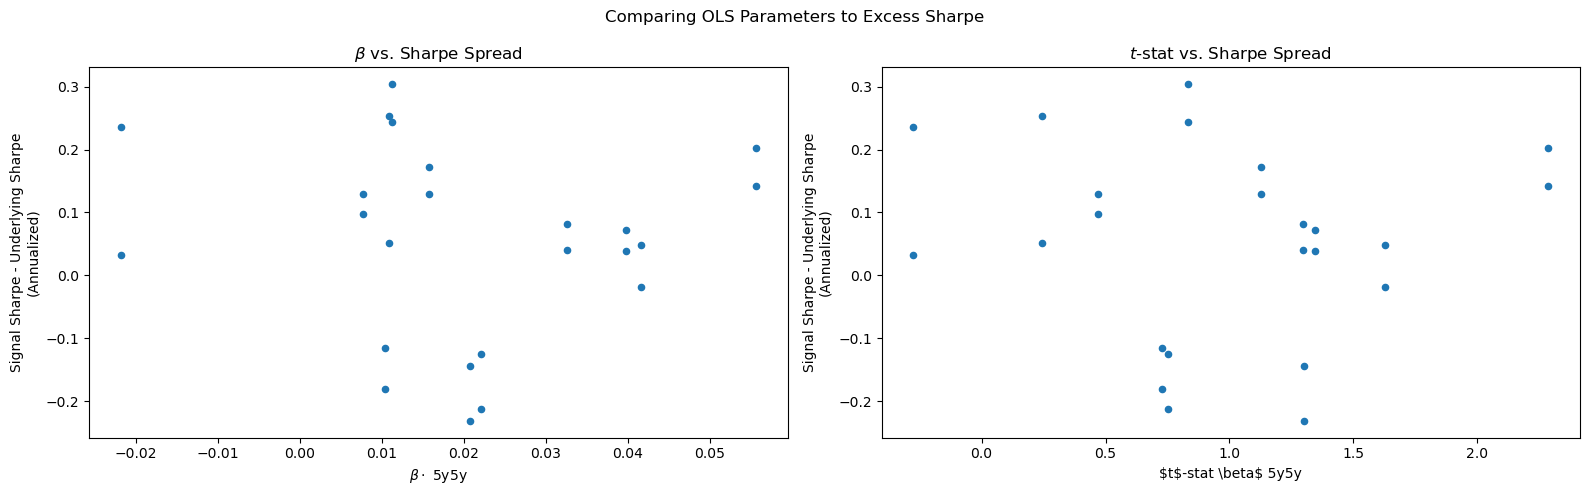

In [14]:
group_vars = ["param_val", "tstat"]
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (16,5))

xrenamer = {
    "param_val": r"$\beta \cdot$ 5y5y",
    "tstat"    : r"$t$-stat \beta$ 5y5y"}

trenamer = {
    "param_val": r"$\beta$",
    "tstat"    : r"$t$-stat"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_tmp_combined.query(
        "index == 'inf_diff'").
        plot(
            ax     = ax,
            kind   = "scatter",
            x      = group_var,
            y      = "sharpe_spread",
            title  = r"{} vs. Sharpe Spread".format(trenamer[group_var]),
            ylabel = "Signal Sharpe - Underlying Sharpe\n(Annualized)",
            xlabel = xrenamer[group_var]))

fig.suptitle("Comparing OLS Parameters to Excess Sharpe")
plt.tight_layout()

Text(0.5, 0.98, 'Correlation of Returns')

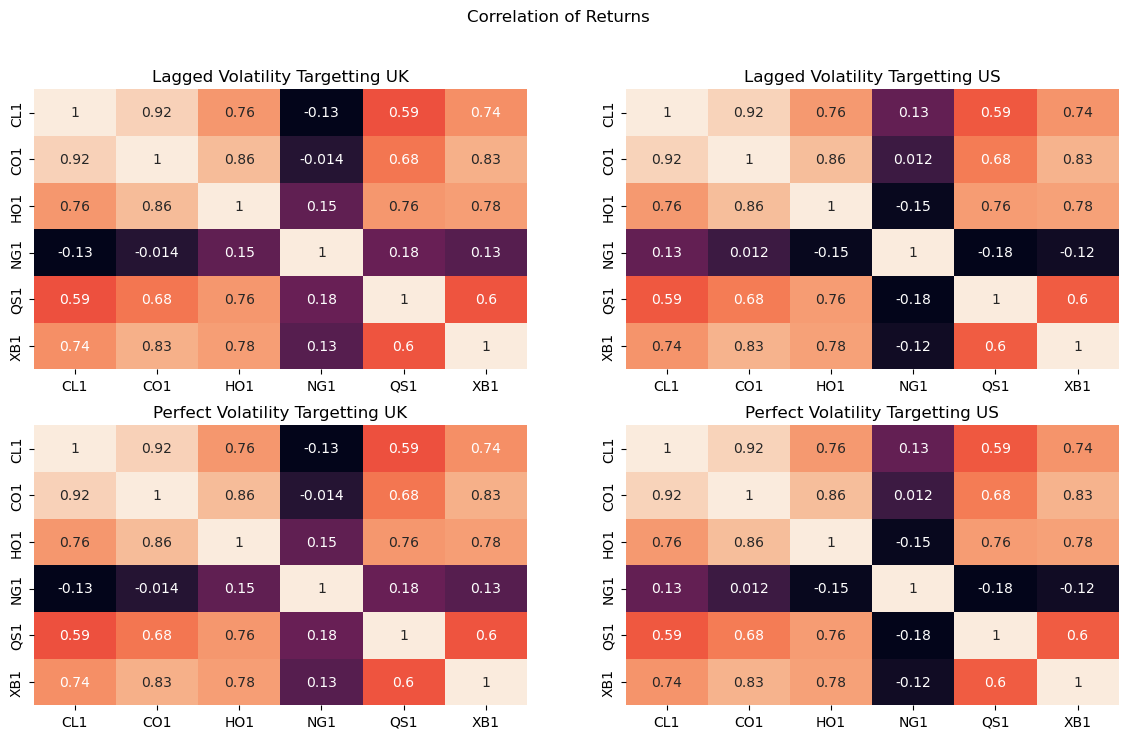

In [15]:
df_plot = (df_rsk_rtn.assign(
    group_var = lambda x: x.group + " " + x.country))

groups = (df_plot.
    group_var.
    drop_duplicates().
    sort_values().
    to_list())

fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (14,8))

renamer = {
    "lagged" : "Lagged Volatility Targetting",
    "perfect": "Perfect Volatility Targetting"}

for group, ax in zip(groups, axes.flatten()):
    
    df_corr = (df_plot.query(
        "group_var == @group").
        pivot(index = "date", columns = "security", values = "signal_rtn").
        corr())
    
    sns.heatmap(
        data  = df_corr, 
        ax    = ax,
        annot = True,
        cbar  = False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(renamer[group.split(" ")[0]] + " " + group.split(" ")[1])
    
fig.suptitle("Correlation of Returns")

In [16]:
df_und_corr = (pd.concat([
    df_raw_lagged, df_raw_perf]).
    pivot(index = ["date", "group"], columns = "security", values = "rtn").
    reset_index().
    drop(columns = ["date"]).
    groupby("group").
    apply(lambda x: x.corr()).
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["group", "security1"]).
    query("security1 != security").
    drop(columns = ["security1", "security"]).
    groupby("group").
    agg("mean").
    rename(columns = {"variable": "und_corr"}))

In [17]:
df_sig_corr = (df_rsk_rtn.
    pivot(index = ["date", "group", "country"], columns = "security", values = "rsk_rtn").
    reset_index().
    drop(columns = ["date"]).
    groupby(["group", "country"]).
    apply(lambda x: x.corr()).
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["group", "security1", "country"]).
    query("security1 != security").
    drop(columns = ["security1", "security"]).
    groupby(["group", "country"]).
    agg("mean").
    reset_index())

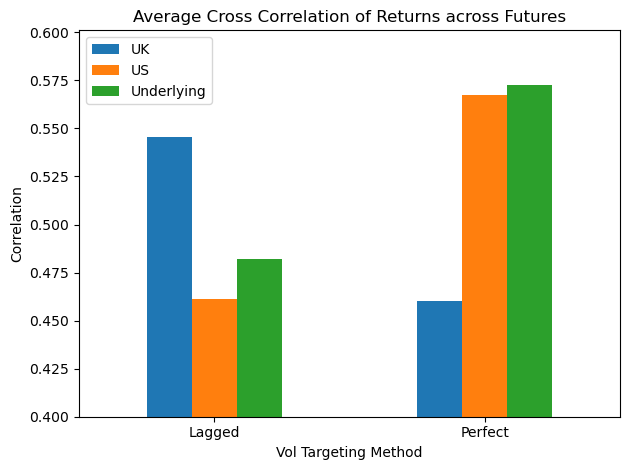

In [18]:
(pd.concat([
    df_sig_corr, df_und_corr.reset_index().assign(country = "und")]).
    rename(columns = {"country": ""}).
    replace({"und": "Underlying"}).
    assign(group = lambda x: x.group.str.capitalize()).
    pivot(index = "group", columns = "", values = "value").
    plot(
        kind   = "bar",
        rot    = 0,
        xlabel = "Vol Targeting Method",
        ylabel = "Correlation",
        ylim   = 0.4,
        title  = "Average Cross Correlation of Returns across Futures"))

plt.tight_layout()

# Section 2: Trading Model Based on Residuals of OLS Full Sample

In [19]:
def _get_resid(df: pd.DataFrame) -> pd.DataFrame: 
    
    df_out = (sm.OLS(
        endog = df.fut_rtn,
        exog  = sm.add_constant(df.inf_diff)).
        fit().
        resid.
        to_frame(name = "resid").
        assign(
            lag_resid = lambda x: x.resid.shift(),
            decile    = lambda x: pd.qcut(x = x.resid, q = 10, labels = [i + 1 for i in range(10)]).shift()).
        merge(right = df, how = "inner", on = ["date"]))
    
    return df_out
    
df_ols = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x).diff()).
    reset_index().
    melt(id_vars = ["date"], value_name = "inf_diff").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_resid, include_groups = False).
    reset_index())

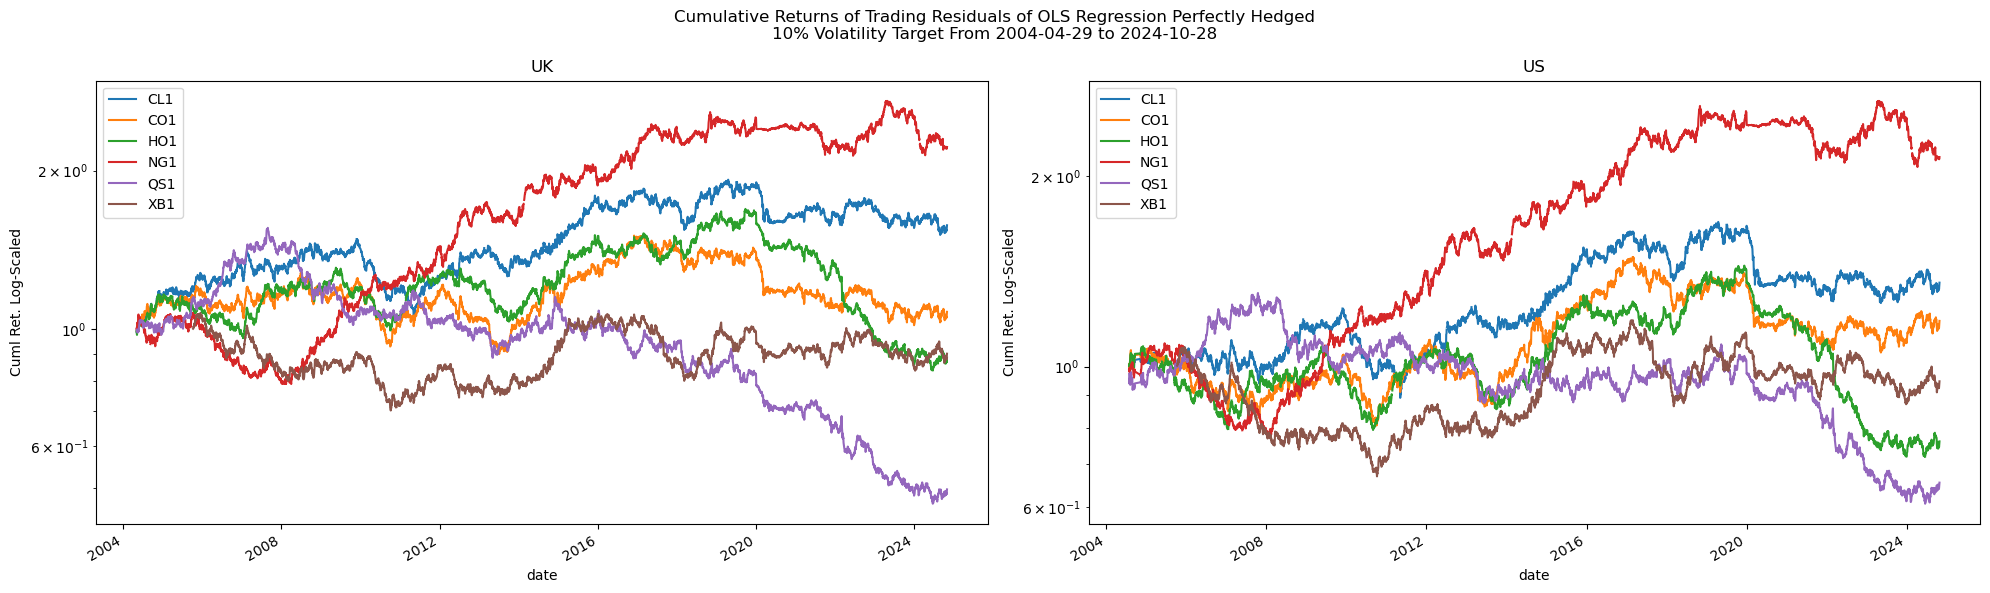

In [20]:
countrys  = df_ols.country.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(countrys), figsize = (20,6)) 

for country, ax in zip(countrys, axes.flatten()):

    (df_ols.assign(
        signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
        query("country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = country,
            ylabel = "Cuml Ret. Log-Scaled"))
    
fig.suptitle("Cumulative Returns of Trading Residuals of OLS Regression Perfectly Hedged\n10% Volatility Target From {} to {}".format(
    df_ols.date.min().date(),
    df_ols.date.max().date()))

plt.tight_layout()

Below is a table of the sharpes for trading the residuals

In [21]:
(df_ols.assign(
    signal_rtn = lambda x: -np.sign(x.lag_resid) * x.fut_rtn).
    pivot(index = "date", columns = ["country", "security"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(255)))).
    reset_index().
    melt(id_vars = [('date',    '')], value_name = "rtn").
    drop(columns = [('date',    '')]).
    dropna().
    groupby(["country", "security"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    pivot(index = "security", columns = "country", values = "rtn").
    apply(lambda x: np.round(x,3)))

country,UK,US
security,,
CL1,0.280,0.209
CO1,0.087,0.132
HO1,-0.014,-0.094
NG1,0.461,0.453
QS1,-0.294,-0.161
XB1,-0.010,0.019


# Section 3: Trading Model based on Deciles of OLS Residuals

In [22]:
df_decile_sharpe = (df_ols[
    ["group_var", "decile", "fut_rtn"]].
    dropna().
    groupby(["group_var", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"fut_rtn": "sharpe"}))

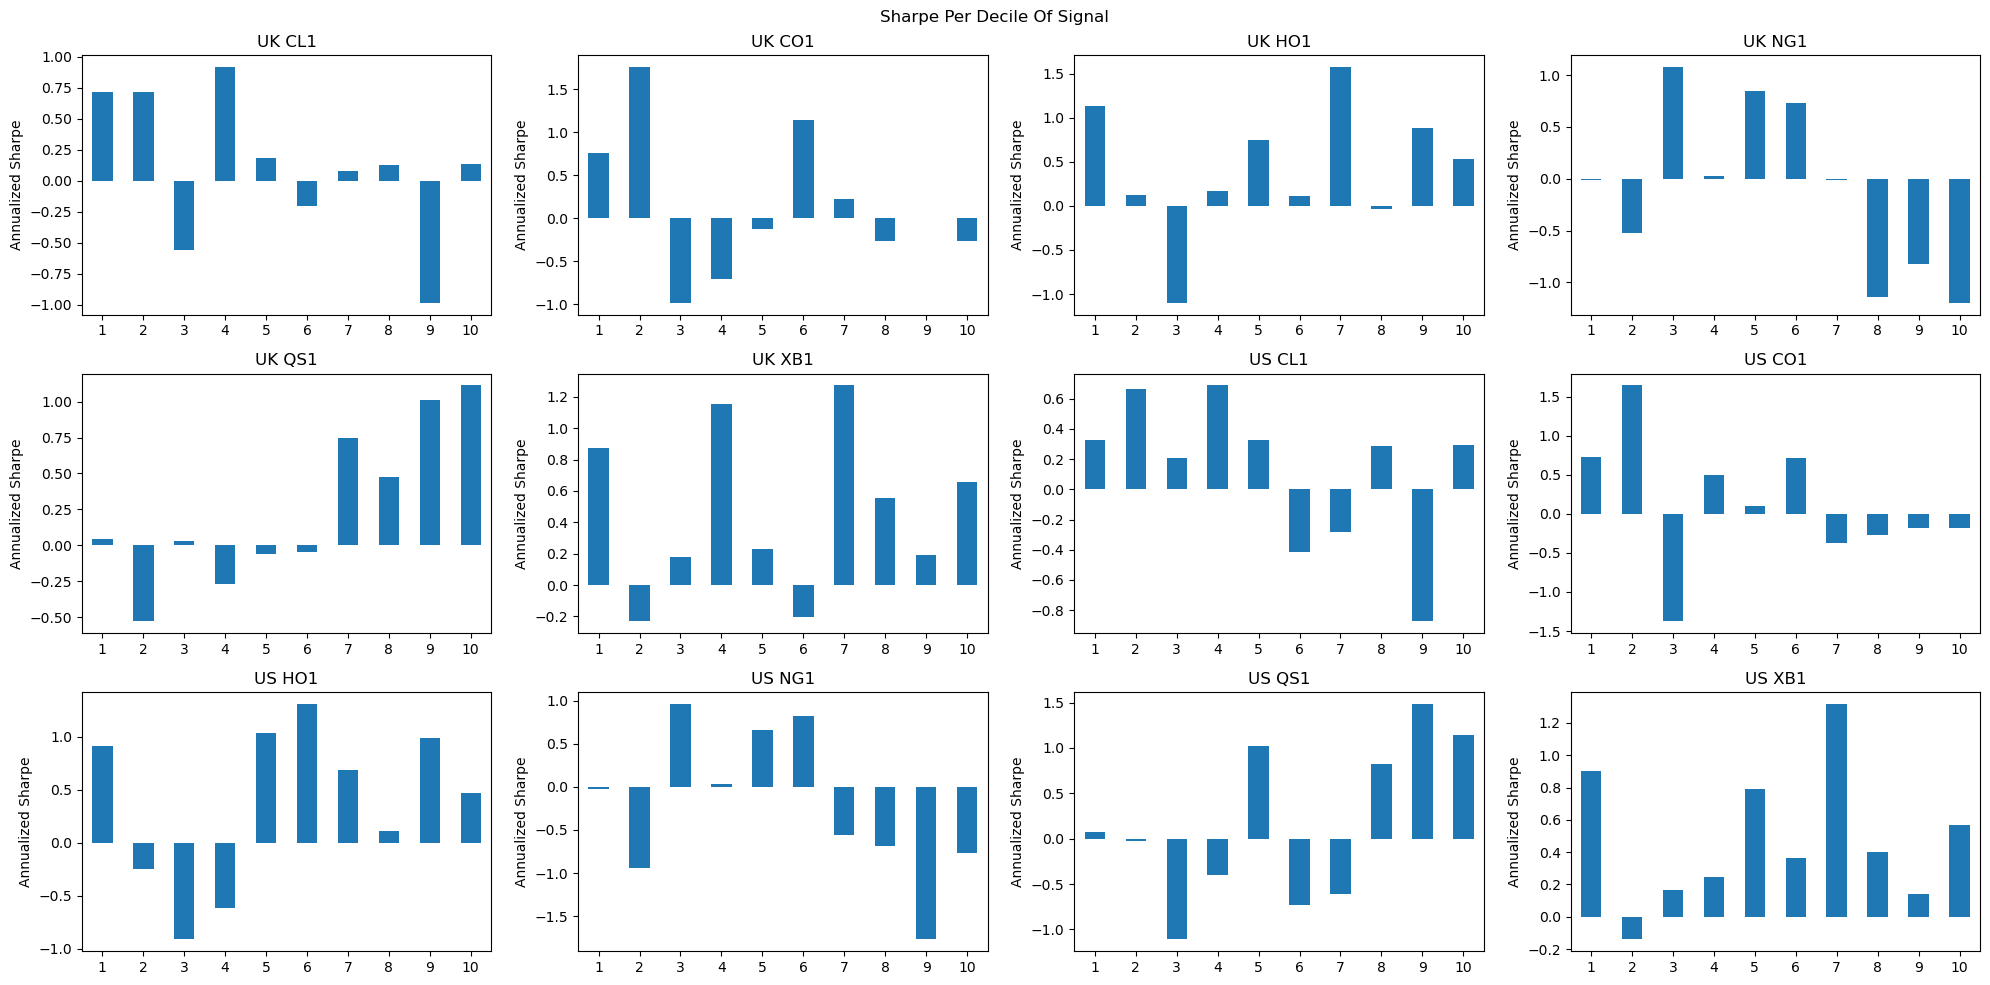

In [23]:
group_vars = df_decile_sharpe.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 4, nrows = 3, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_decile_sharpe.query(
        "group_var == @group_var").
         set_index("decile")
        [["sharpe"]].
        plot(
            ax     = ax,
            kind   = "bar", 
            ylabel = "Annualized Sharpe",
            title  = group_var,
            xlabel = "",
            rot    = 0,
            legend = False))
    
fig.suptitle("Sharpe Per Decile Of Signal")
plt.tight_layout()

From the sharpes above we can see which tickers will have good returnn. HO and XB have weak bar charts and we'll likely find that the signal is not that good to trade. 

In [24]:
df_decile_group = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(tmp_group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [25]:
df_decile_rtn = (df_decile_group.drop(
    columns = ["decile"]).
    groupby(["group_var", "tmp_group"]).
    agg("prod").
    rename(columns = {"sharpe": "scaler"}).
    reset_index().
    merge(right = df_decile_group, how = "inner", on = ["group_var", "tmp_group"]).
    assign(signal = lambda x: np.where(x.scaler > 0, np.sign(x.scaler * x.sharpe), 0))
    [["group_var", "decile", "signal"]].
    merge(right = df_ols, how = "outer", on = ["group_var", "decile"]).
    assign(
        signal     = lambda x: x.signal.fillna(0),
        signal_rtn = lambda x: np.sign(x.signal) * x.fut_rtn))

In [26]:
df_wider = (df_decile_rtn.pivot(
    index = "date", columns = ["security", "country"], values = "signal_rtn"))

In [27]:
df_lag = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", '')],  value_name = "signal_rtn").
    rename(columns = {("date", ''): "date"}).
    assign(group = "lag_vol"))

df_perf = (df_wider.apply(
    lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) == np.inf, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", '')],  value_name = "signal_rtn").
    rename(columns = {("date", ''): "date"}).
    assign(group = "perf_vol"))

df_stacked = (pd.concat([
    df_lag, df_perf]).
    dropna())

In [28]:
df_avg = (df_stacked.drop(
    columns = ["security"]).
    groupby(["date", "country", "group"]).
    agg("mean").
    reset_index().
    assign(security = "average"))

df_ex = (df_stacked.query(
    "security != ['HO1', 'XB1']").
    drop(columns = ["security"]).
    groupby(["date", "country", "group"]).
    agg("mean").
    reset_index().
    assign(security = "ex"))

df_combined = pd.concat([df_stacked, df_avg, df_ex])

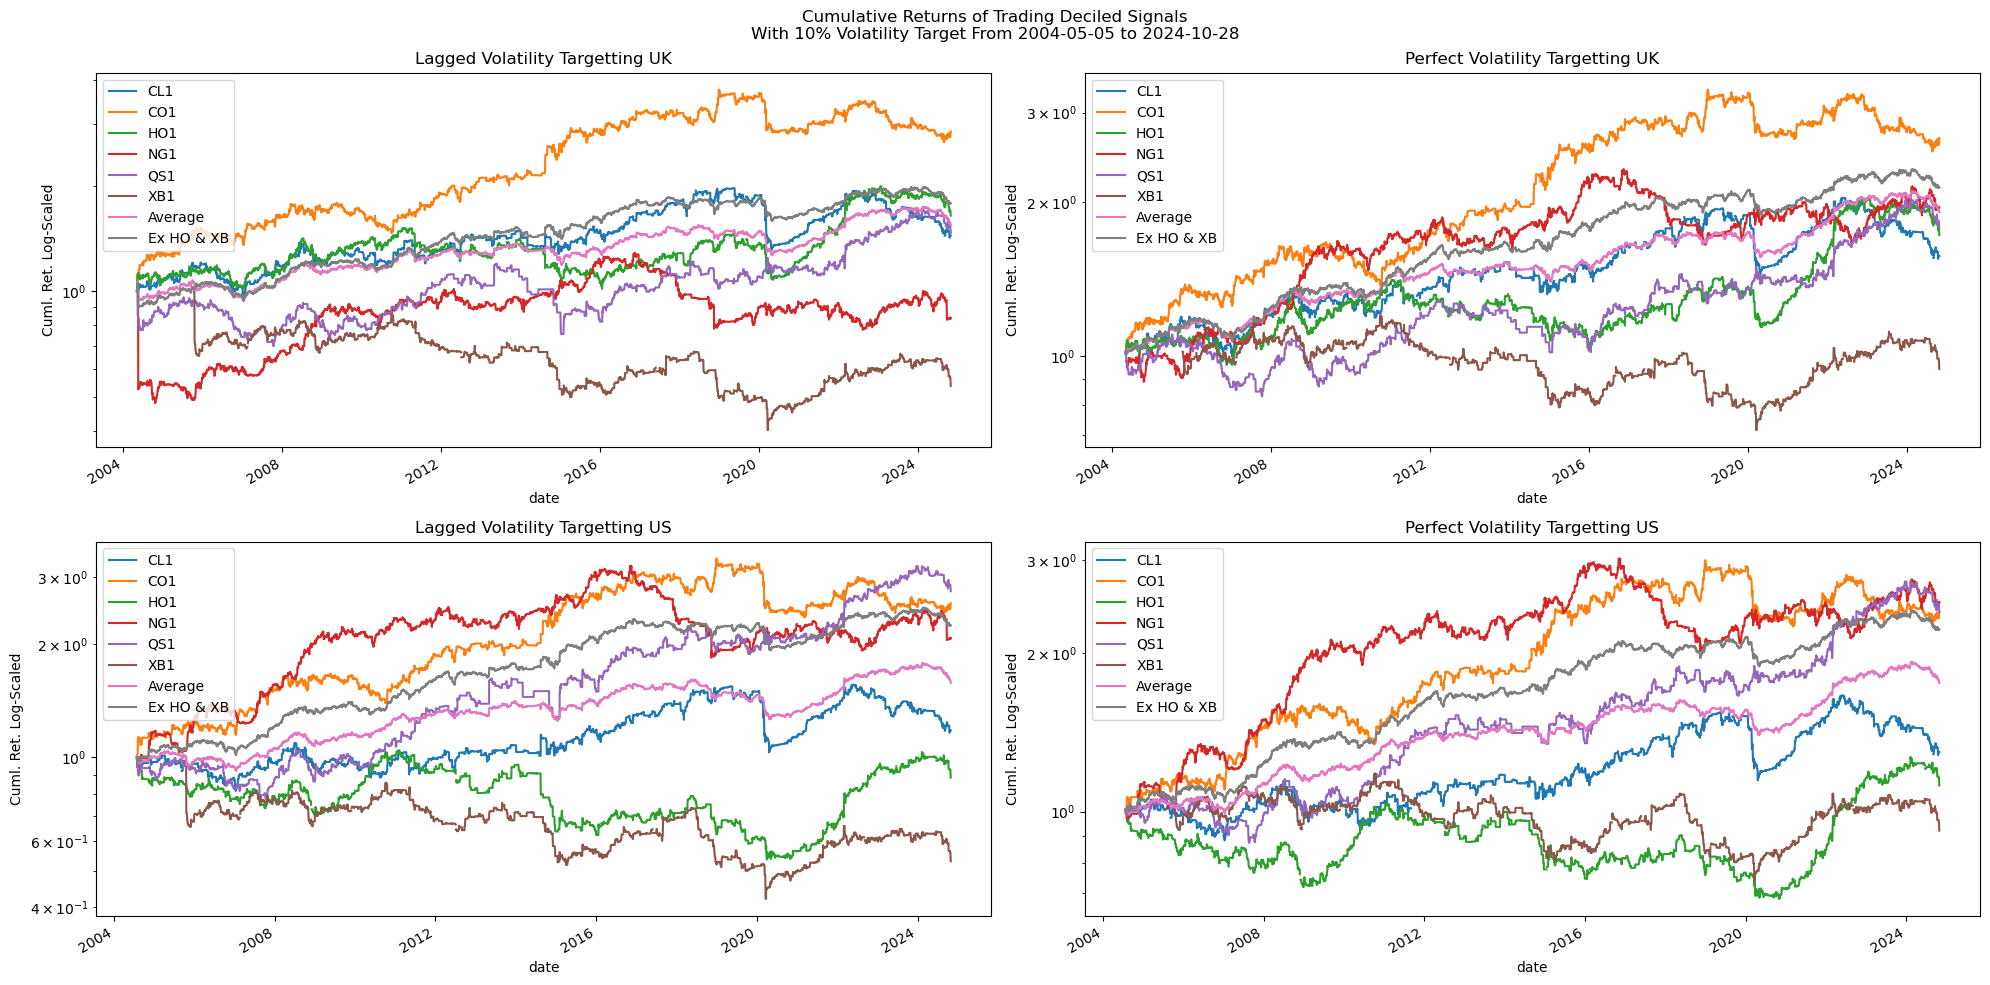

In [29]:
df_tmp = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.group))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

renamer = {
    "lag_vol" : "Lagged Volatility Targetting",
    "perf_vol": "Perfect Volatility Targetting"}

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_tmp.query(
        "group_var == @group_var").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        rename(columns = {
            "average": "Average",
            "ex"     : "Ex HO & XB"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[group_var.split(" ")[1]] + " " + group_var.split(" ")[0]))
    
fig.suptitle("Cumulative Returns of Trading Deciled Signals\nWith 10% Volatility Target From {} to {}".format(
    df_tmp.date.min().date(),
    df_tmp.date.max().date()))

plt.tight_layout()

In [30]:
(df_combined.assign(
    adj_rtn = lambda x: np.where(x.signal_rtn == 0, np.nan, x.signal_rtn)).
    melt(id_vars = ["date", "security", "country", "group"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["security", "country", "group", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "average"   : "Average",
        "ex"        : "Ex HO & XB",
        "adj_rtn"   : "Adjusted Sharpe",
        "signal_rtn": "Raw Sharpe",
        "lag_vol"   : "Lag Targetting",
        "perf_vol"  : "Perfect Targetting"}).
    rename(columns = {
        "group"   : "Volatility Method",
        "variable": ""}).
    pivot(index = ["security", "country"], columns = ["Volatility Method", ""], values = "value").
    apply(lambda x: np.round(x,3)))

Volatility Method   Lag Targetting            Perfect Targetting           
                   Adjusted Sharpe Raw Sharpe    Adjusted Sharpe Raw Sharpe
security   country                                                         
Average    UK                0.444      0.378              0.825      0.702
           US                0.535      0.451              0.811      0.683
CL1        UK                0.492      0.220              0.651      0.291
           US                0.293      0.131              0.426      0.191
CO1        UK                0.813      0.513              0.854      0.539
           US                0.761      0.481              0.785      0.495
Ex HO & XB UK                0.554      0.454              0.917      0.751
           US                0.834      0.684              0.988      0.809
HO1        UK                0.449      0.284              0.530      0.335
           US                0.003      0.001              0.245      0.110
NG1        UK                0.063      0.040              0.629      0.397
           US                0.608      0.384              0.846      0.533
QS1        UK                0.475      0.211              0.777      0.346
           US                1.040      0.462              1.154      0.513
XB1        UK               -0.419     -0.187              0.027      0.012
           US               -0.431     -0.192             -0.005     -0.002

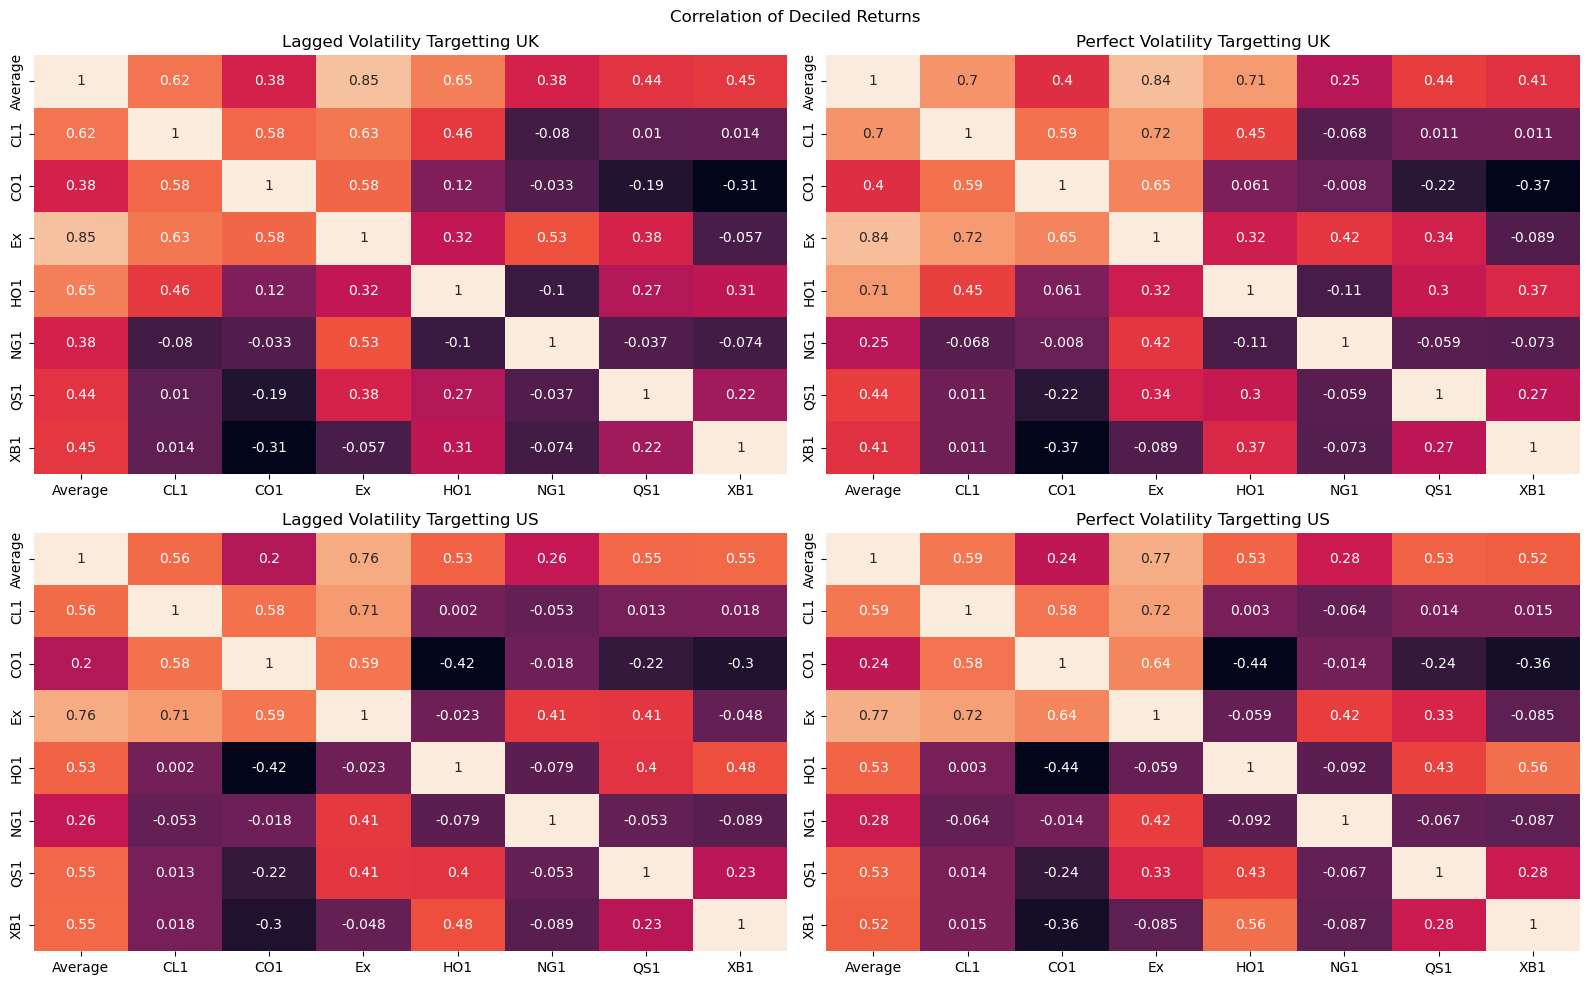

In [31]:
df_tmp = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.group))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = 2, nrows = 2, figsize = (16,10))

for group_var, ax in zip(group_vars, axes.flatten()): 
    
    df_corr = (df_tmp.query(
        "group_var == @group_var").
        replace({
            "average": "Average",
            "ex"     : "Ex"}).
        pivot(index = "date", columns = "security", values = "signal_rtn").
        corr().
        apply(lambda x: np.round(x,3)))
    
    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        annot = True,
        cbar  = False)
    
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(renamer[group_var.split(" ")[1]] + " " + group_var.split(" ")[0])
    
fig.suptitle("Correlation of Deciled Returns")
plt.tight_layout()

# Section 4: Trading Z-Score of the 5y5y Forward Inflation

In [32]:
window = 30

df_decile = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x).diff()).
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    apply(lambda x: pd.qcut(x = x, q = 10, labels = [i + 1 for i in range(10)])).
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "decile").
    dropna())

In [33]:
df_combined = (df_fut_rtn.merge(
    right = df_decile, how = "inner", on = ["date"]))

In [34]:
df_decile_sharpe = (df_combined.drop(
    columns = ["date"]).
    groupby(["security", "country", "decile"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index())

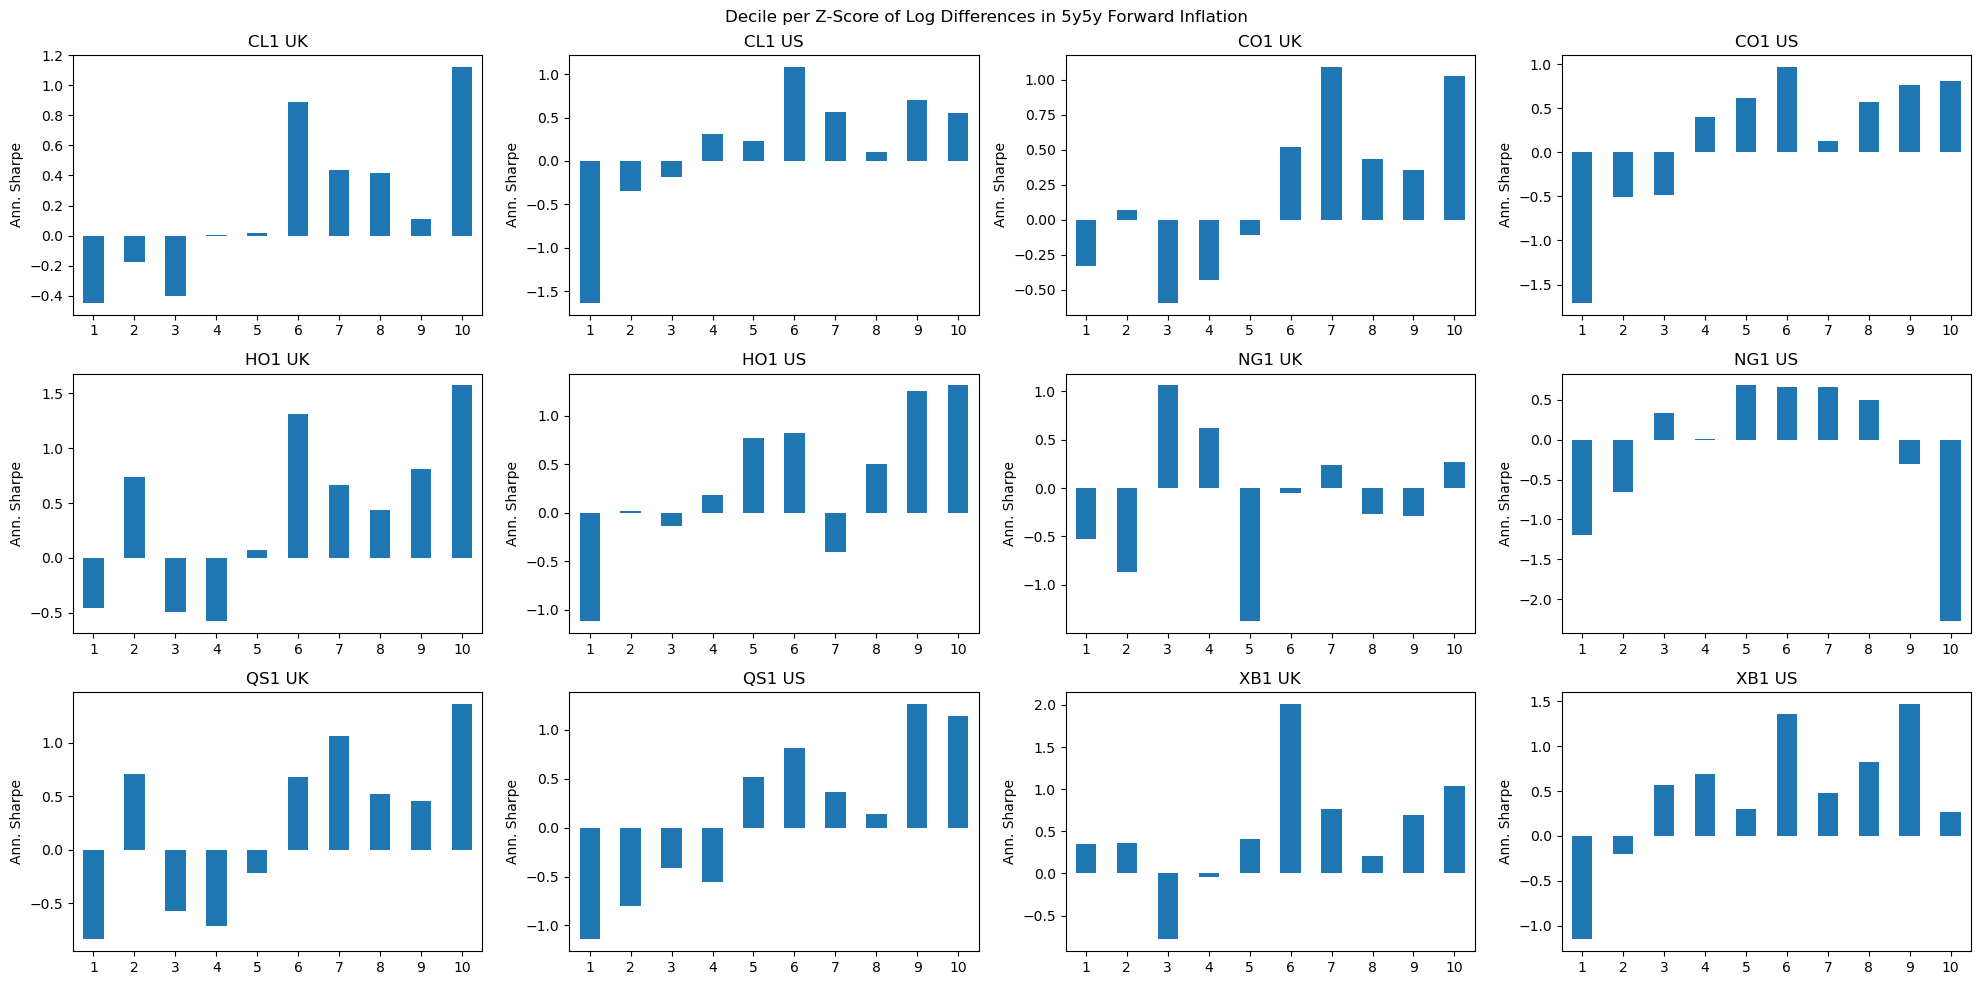

In [35]:
df_tmp = (df_decile_sharpe.assign(
    group_var = lambda x: x.security + " " + x.country))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 3, nrows = len(group_vars) // 4, figsize = (20,10))

for group_var, ax in zip(group_vars, axes.flatten()):
    
    (df_tmp.query(
        "group_var == @group_var").
        set_index("decile")
        [["fut_rtn"]].
        plot(
            ax     = ax,
            kind   = "bar",
            rot    = 0,
            legend = False,
            xlabel = "",
            ylabel = "Ann. Sharpe",
            title  = group_var))

fig.suptitle("Decile per Z-Score of Log Differences in 5y5y Forward Inflation")
plt.tight_layout()

In [36]:
df_decile_group = (df_decile_sharpe.query(
    "decile == [1,2,9,10]").
    assign(decile_group = lambda x: np.where(x.decile <= 2, "lower_group", "upper_group")))

In [37]:
df_decile_rtn = (df_decile_group.drop(
    columns = ["decile"]).
    groupby(["security", "country", "decile_group"]).
    agg("prod").
    reset_index().
    assign(scaler = lambda x: np.where(x.fut_rtn > 0, 1, 0)).
    drop(columns = ["fut_rtn"]).
    merge(right = df_decile_group, how = "inner", on = ["security", "country", "decile_group"]).
    rename(columns = {"fut_rtn": "sharpe"}).
    merge(right = df_combined, how = "outer", on = ["security", "country", "decile"]).
    drop(columns = ["decile_group"]).
    assign(signal_rtn = lambda x: np.sign(x.sharpe * x.scaler) * x.fut_rtn))

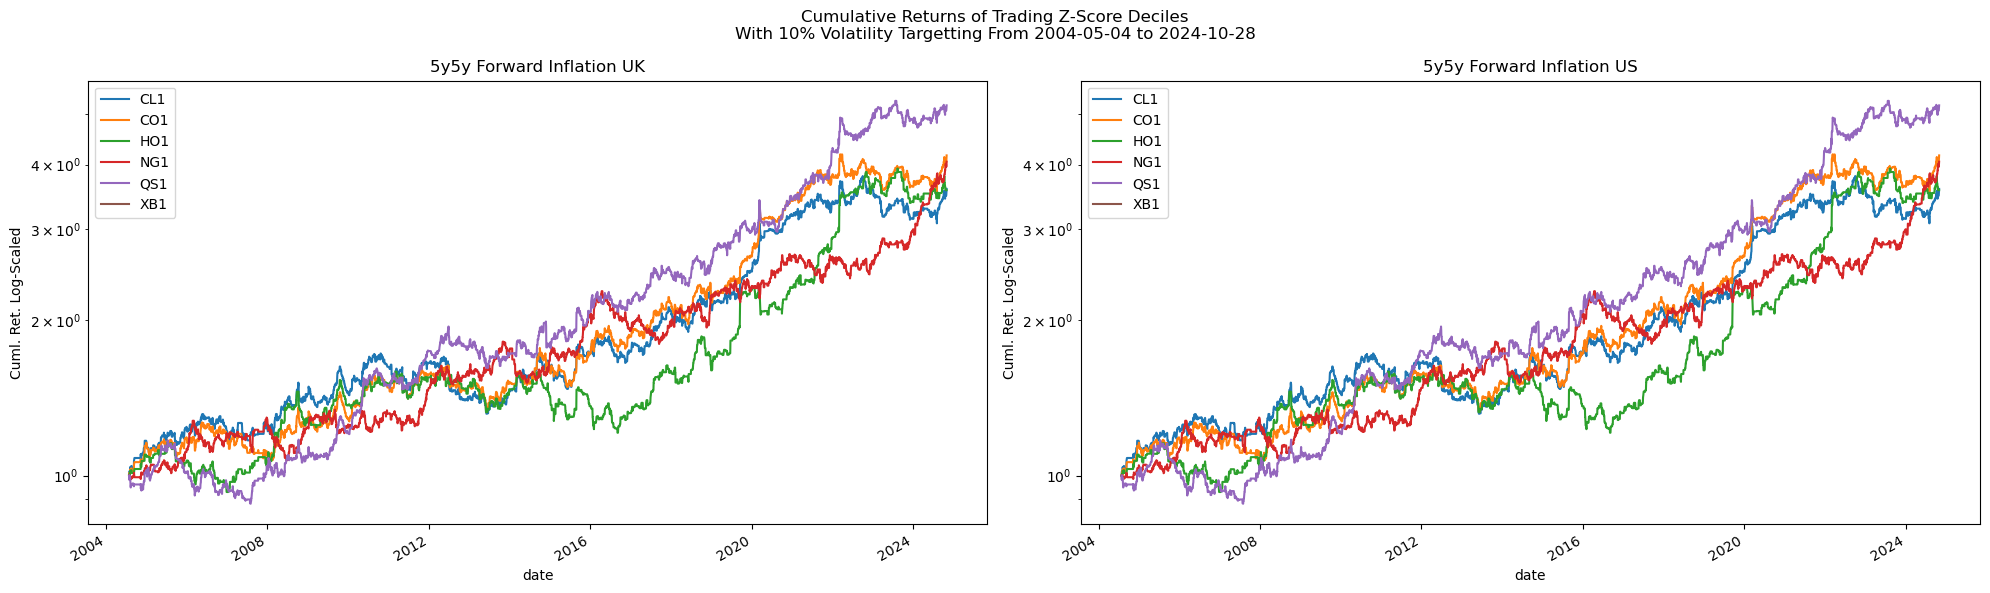

In [38]:
group_vars = df_decile_rtn.country.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

for group_var, ax in zip(group_vars, axes.flatten()): 
    
    (df_decile_rtn.query(
        "country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        fillna(0).
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            title  = "5y5y Forward Inflation {}".format(group_var),
            ylabel = "Cuml. Ret. Log-Scaled"))
    
fig.suptitle("Cumulative Returns of Trading Z-Score Deciles\nWith 10% Volatility Targetting From {} to {}".format(
    df_decile_rtn.date.min().date(),
    df_decile_rtn.date.max().date()))

plt.tight_layout()

In [39]:
(df_decile_rtn.assign(
    raw_rtn = lambda x: x.signal_rtn.fillna(0))
    [["security", "country", "date", "signal_rtn", "raw_rtn"]].
    melt(id_vars = ["date", "security", "country"]).
    dropna().
    drop(columns = ["date"]).
    groupby(["security", "country", "variable"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    replace({
        "raw_rtn"   : "Raw Sharpe",
        "signal_rtn": "Adj Sharpe"}).
    rename(columns = {"variable": ""}).
    pivot(index = ["security", "country"], columns = "", values = "value").
    apply(lambda x: np.round(x,3)))

Adj Sharpe  Raw Sharpe
security country                        
CL1      UK            0.458       0.291
         US            0.839       0.532
CO1      UK            0.501       0.317
         US            0.965       0.611
HO1      UK            0.866       0.550
         US            0.901       0.571
NG1      UK            0.491       0.312
         US            1.098       0.695
QS1      UK            0.682       0.432
         US            1.096       0.693
XB1      UK            0.601       0.386
         US            0.747       0.473

Below is a table of the correlation matrix of the returns. 

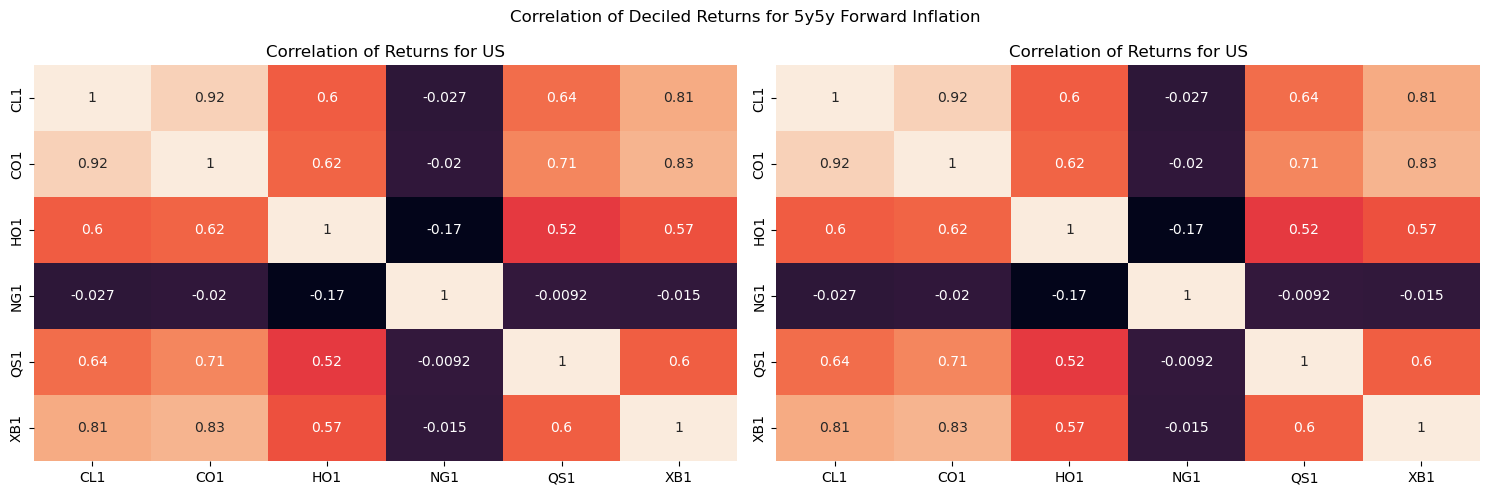

In [40]:
group_vars = df_decile_rtn.country.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (15,5))

for group_var, ax in zip(group_vars, axes.flatten()): 
    
    df_corr = (df_decile_rtn.query(
        "country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn").
        fillna(0).
        apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
        corr())
    
    sns.heatmap(
        data  = df_corr,
        ax    = ax,
        cbar  = False,
        annot = True)
    
    ax.set_title("Correlation of Returns for {}".format(country))
    
fig.suptitle("Correlation of Deciled Returns for 5y5y Forward Inflation")
plt.tight_layout()

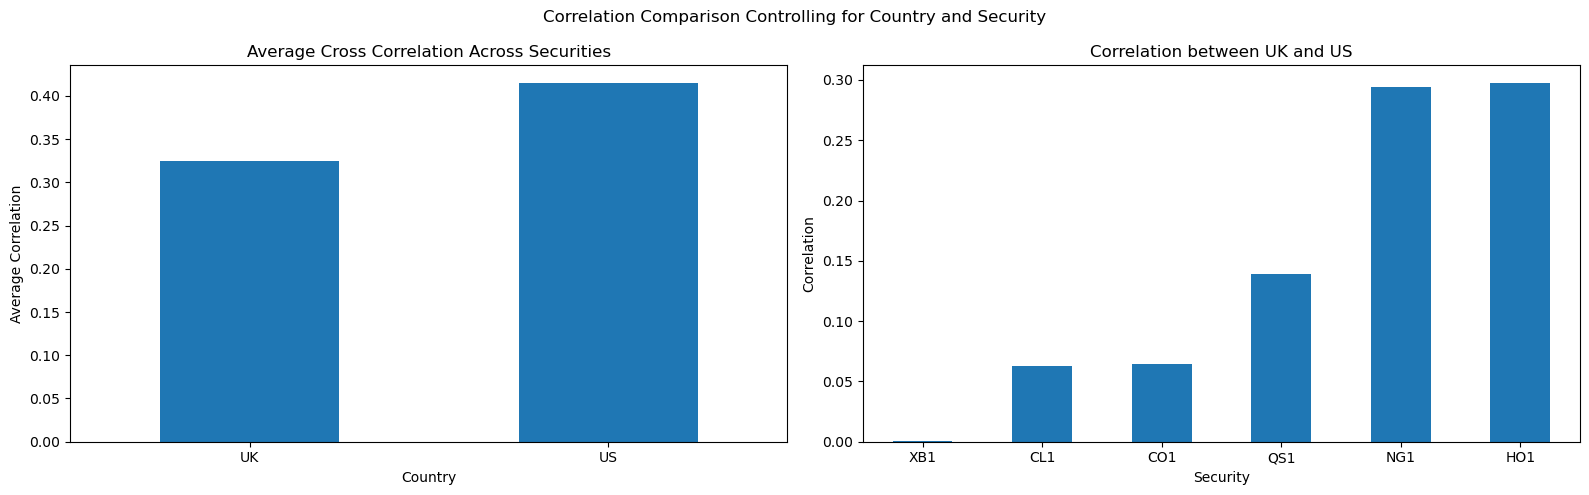

In [41]:
fig, axes = plt.subplots(ncols = 2, figsize = (16,5))

(df_decile_rtn.pivot(
    index = ["date", "country"], columns = "security", values = "signal_rtn").
    fillna(0).
    reset_index().
    drop(columns = ["date"]).
    groupby("country").
    agg("corr").
    reset_index().
    rename(columns = {"security": "security1"}).
    melt(id_vars = ["country", "security1"]).
    query("security1 != security")
    [["country", "value"]].
    groupby("country").
    agg("mean").
    plot(
        kind = "bar",
        ax   = axes[0],
        legend = False,
        xlabel = "Country",
        ylabel = "Average Correlation",
        rot    = 0,
        title  = "Average Cross Correlation Across Securities"))

(df_decile_rtn.pivot(
    index = ["date", "security"], columns = "country", values = "signal_rtn").
    fillna(0).
    reset_index().
    drop(columns = ["date"]).
    groupby("security").
    agg("corr")
    [["US"]].
    query("US != 1").
    reset_index().
    set_index("security")
    [["US"]].
    sort_values("US").
    plot(
        kind   = "bar", 
        ax     = axes[1],
        legend = False,
        rot    = 0,
        xlabel = "Security",
        title  = "Correlation between UK and US",
        ylabel = "Correlation"))

fig.suptitle("Correlation Comparison Controlling for Country and Security")
plt.tight_layout()

In [42]:
df_risk_rtn = (df_decile_rtn.pivot(
    index = "date", columns = ["security", "country"], values = "signal_rtn").
    apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
    reset_index().
    melt(id_vars = [("date", "")], value_name = "signal_rtn").
    rename(columns = {('date', ''): "date"}))

In [43]:
df_country = (df_risk_rtn.drop(
    columns = ["security"]).
    groupby(["date", "country"]).
    agg("mean").
    reset_index())

In [44]:
df_all = (df_risk_rtn[
    ["date", "signal_rtn"]].
    groupby("date").
    agg("mean").
    assign(country = "All").
    reset_index())

<Axes: title={'center': 'Cumulative Returns of Trading All Energy Portfolios'}, xlabel='date', ylabel='Cuml. Ret. Log-Scaled'>

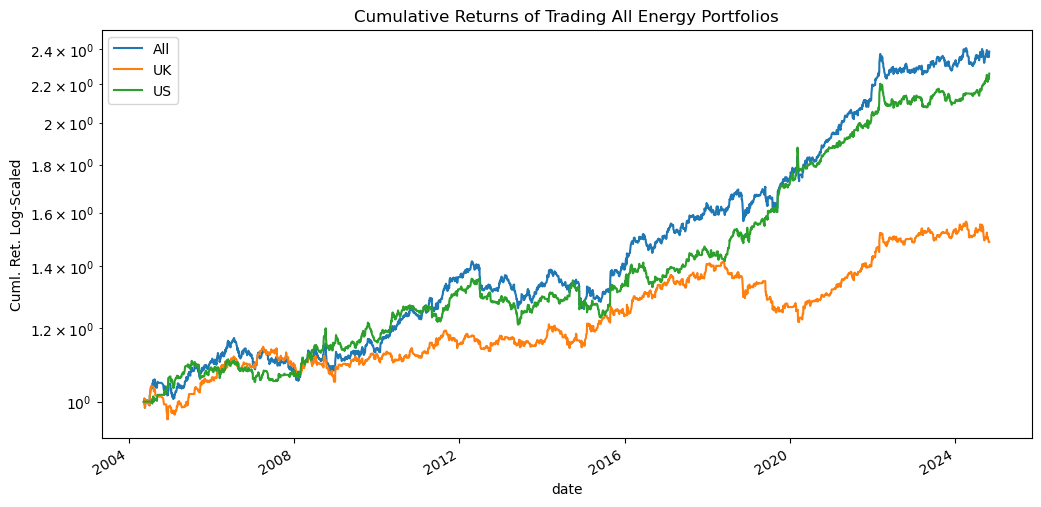

In [45]:
(pd.concat([
    df_country, df_all]).
    rename(columns = {"country": ""}).
    assign(tmp = lambda x: x.signal_rtn.abs()).
    query("tmp <= 0.3").
    pivot(index = "date", columns = "", values = "signal_rtn").
    fillna(0).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        figsize = (12,6),
        title   = "Cumulative Returns of Trading All Energy Portfolios"))

# Appendix: For Writeup

## Section 1: For Energy Future information

In [ ]:
print(df_rtn[
    ["security", "date"]].
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    drop_duplicates().
    groupby("security").
    agg(["min", "max"])
    ["date"].
    rename(columns = {
        "min": "Start Date",
        "max": "End Date"}).
    to_latex())

## Section 1: For Latex Table OLS Results

In [ ]:
print(df_ols_params.
    melt(id_vars = ["country", "security", "index", "rtn_type"]).
    rename(columns = {
        "variable": "",
        "index"   : "param",
        "rtn_type" : "Vol. Target"}).
    replace({
        "const"    : r"$\alpha$",
        "inf_diff" : r"$\beta$",
        "param_val": "Param. Val.",
        "pvalues"  : r"$p$-value",
        "tstat"    : r"$t$-value"}).
    pivot(index = ["country", "security"], columns = ["", "Vol. Target", "param"], values = "value").
    apply(lambda x: np.round(x,4)).
    to_latex(float_format="%.3f"))

## Section 1: For Chart

In [ ]:
rtn_types = df_model.rtn_type.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(rtn_types), figsize = (20,6))
out_path  = os.path.join("LaTex", "BetaScaledCumlRet.png")

country_color = {
    "UK": "red",
    "US": "blue"}

renamer = {
    "lagged" : "Lagged Volatility Targeting",
    "perfect": "Perfect Volatility Targeting"}

for rtn_type, ax in zip(rtn_types, axes.flatten()): 

    df_tmp         = df_model.query("rtn_type == @rtn_type")
    legend_handles = []
    
    for country in country_color.keys():

        (df_tmp.query(
            "country == @country").
            pivot(index = "date", columns = "security", values = "signal_rtn").
            apply(lambda x: np.cumprod(1 + x)).
            plot(
                ax     = ax,
                legend = False,
                color  = country_color[country],
                ylabel = "Cuml. Ret. Log-Scaled",
                alpha  = 0.7,
                logy   = True))

        legend_handles.append(
            Line2D(
                [0], [0],
                color = country_color[country],
                lw    = 2,
                label = country))

        ax.legend(handles=legend_handles)

    ax.set_title(renamer[rtn_type])

fig.suptitle(
    r"Cumulative Returns of Trading Energy Futures using $\beta$-scaled Lagged 5y5y Forward Swap" + 
    "\n10% Volatility Target From {} to {}".format(
        df_model.date.min().date(),
        df_model.date.max().date()))

plt.show()
fig.savefig(fname = out_path, dpi = 300, bbox_inches = "tight")

## Section 1: For Sharpe

In [ ]:
print(df_sharpe.rename(
    columns = {
        "rtn_type": "Vol Target",
        "country" : "Country"}).
    replace({
        "lagged" : "Lagged",
        "perfect": "Perfect"}).
    pivot(index = "security", columns = ["Country", "Vol Target"], values = "signal_rtn").
    apply(lambda x: np.round(x,3)).
    to_latex(float_format="%.3f"))